We observe that there is more loss with 20 epochs compared to 50. This was expected as the set was less trained. However, we can expect that there is a maximum of epochs, after which the model becomes too specialized on the training data.


In [ ]:
# Imports libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
# Set seaborn style
sns.set_theme(style="whitegrid")

In [ ]:
# Import file
from google.colab import drive

drive.mount('/content/drive')

# 👉 change this path to where your file is in Drive
path = "/content/drive/MyDrive/model_metrics(2).csv"

metrics = pd.read_csv(path)

print("Loaded file from:", path)
display(metrics.head())

Mounted at /content/drive
Loaded file from: /content/drive/MyDrive/model_metrics(2).csv


,training_data,timestamp,train_samples,train_features,nb_epoch,best_batch,from_batch_sizes,layer1_size,layer2_size,loss,mse,mae,r2
0,kinase.csv,2026-04-07T08:56:22.229163,125407,167,50,32,"[16, 32, 64]",64,32,1.025206,1.025206,0.800054,0.414686
1,kinase.csv,2026-04-07T09:30:47.000239,125407,167,20,16,"[16, 32, 64]",64,32,1.085186,1.085186,0.821824,0.380443
2,kinase.csv,2026-04-08T16:45:11.188885,7000,167,50,32,"[16, 32, 64]",64,32,1.862967,1.862967,1.068465,-0.009459
3,ERa_activity.csv,2026-04-08T17:02:22.026022,1381,167,50,32,"[16, 32, 64]",64,32,0.539108,0.539108,0.557236,0.737294


In [ ]:
# Summary
print("\nSummary statistics:")
display(metrics.describe())

print("\nUnique values:")
print("train_samples:", metrics["train_samples"].unique())
print("nb_epoch:", metrics["nb_epoch"].unique())
print("best_batch:", metrics["best_batch"].unique())


Summary statistics:


,train_samples,train_features,nb_epoch,best_batch,layer1_size,layer2_size,loss,mse,mae,r2
count,4.000000,4.0,4.0,4.0,4.0,4.0,4.000000,4.000000,4.000000,4.000000
mean,64798.750000,167.0,42.5,28.0,64.0,32.0,1.128117,1.128117,0.811895,0.380741
std,70021.964299,0.0,15.0,8.0,0.0,0.0,0.547531,0.547531,0.208900,0.305798
min,1381.000000,167.0,20.0,16.0,64.0,32.0,0.539108,0.539108,0.557236,-0.009459
25%,5595.250000,167.0,42.5,28.0,64.0,32.0,0.903682,0.903682,0.739350,0.282967
50%,66203.500000,167.0,50.0,32.0,64.0,32.0,1.055196,1.055196,0.810939,0.397565
75%,125407.000000,167.0,50.0,32.0,64.0,32.0,1.279631,1.279631,0.883484,0.495338
max,125407.000000,167.0,50.0,32.0,64.0,32.0,1.862967,1.862967,1.068465,0.737294



Unique values:
train_samples: [125407   7000   1381]
nb_epoch: [50 20]
best_batch: [32 16]



Average metrics per batch size:


,best_batch,loss,mse,mae,r2
0,16,1.085186,1.085186,0.821824,0.380443
1,32,1.142427,1.142427,0.808585,0.380840


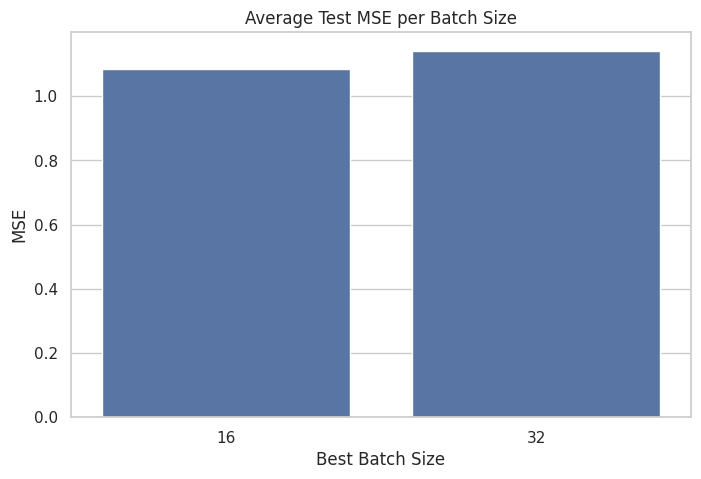

In [ ]:
#compare batch sizes in average
if "best_batch" in metrics.columns:
    batch_summary = metrics.groupby("best_batch")[["loss", "mse", "mae", "r2"]].mean().reset_index()
    print("\nAverage metrics per batch size:")
    display(batch_summary)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=batch_summary, x="best_batch", y="mse")
    plt.title("Average Test MSE per Batch Size")
    plt.ylabel("MSE")
    plt.xlabel("Best Batch Size")
    plt.show()

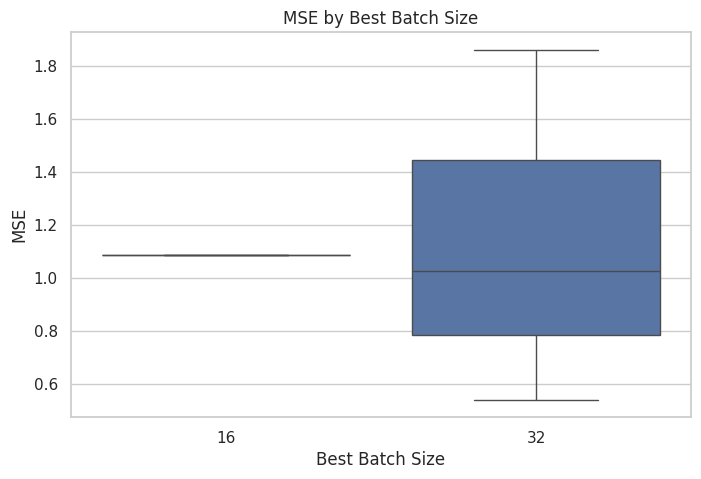

In [ ]:
#compare batch sizes
plt.figure(figsize=(8,5))
sns.boxplot(data=metrics, x="best_batch", y="mse")
plt.title("MSE by Best Batch Size")
plt.xlabel("Best Batch Size")
plt.ylabel("MSE")
plt.show()

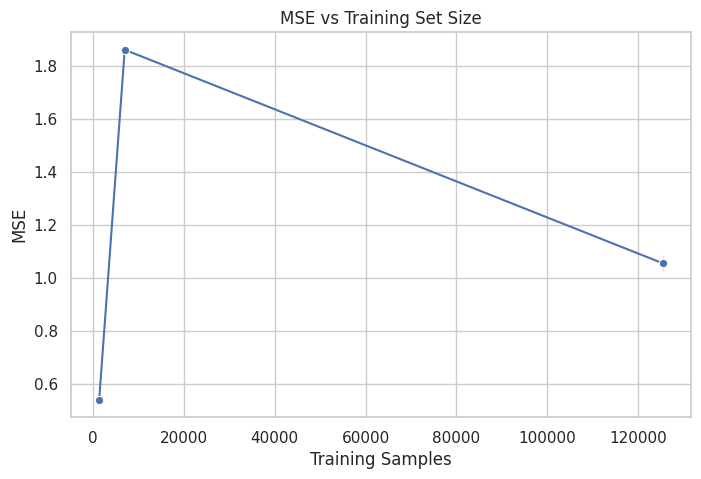

In [ ]:
# Performance vs training size
plt.figure(figsize=(8,5))
sns.lineplot(data=metrics, x="train_samples", y="mse", marker="o")
plt.title("MSE vs Training Set Size")
plt.xlabel("Training Samples")
plt.ylabel("MSE")
plt.show()

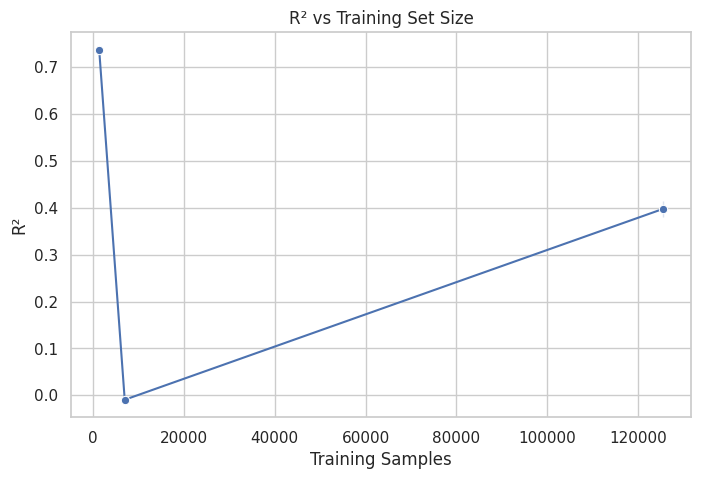

In [ ]:
# R^2 vs training size
plt.figure(figsize=(8,5))
sns.lineplot(data=metrics, x="train_samples", y="r2", marker="o")
plt.title("R² vs Training Set Size")
plt.xlabel("Training Samples")
plt.ylabel("R²")
plt.show()

In [ ]:
# best configuration
best_model = metrics.loc[metrics["mse"].idxmin()]

print("Best model (lowest MSE):")
display(best_model)

Best model (lowest MSE):


,3
training_data,ERa_activity.csv
timestamp,2026-04-08T17:02:22.026022
train_samples,1381
train_features,167
nb_epoch,50
best_batch,32
from_batch_sizes,"[16, 32, 64]"
layer1_size,64
layer2_size,32
loss,0.539108
